# NB10 — Analysis and paper figures

This notebook is read-only with respect to experiment inputs: it pulls public
HF artifacts, builds the master tables, renders Figures 1–10, reports all three
preregistered outcomes whether supported or not, then pushes only the derived
analysis files. A figure whose upstream notebook is incomplete is explicitly
marked skipped; it is never fabricated from a fallback.


In [10]:
# === CELL 1 of every notebook: unpack the library ==========================
# Writes tyrelib.py into the session and imports it. Nothing here touches the
# GPU or the network beyond installing three small packages.
#
#   tyrelib   the whole pipeline: HuggingFace sync, registry, work sharding,
#             telemetry, model zoo, training loop, metrics.
#
# Generated by build_notebooks.py from tyrelib.py. Editing the blob below does
# nothing useful -- the next rebuild overwrites it. Edit the source instead.
import base64, subprocess, sys
from pathlib import Path

WORK = Path('/kaggle/working') if Path('/kaggle/working').is_dir() else Path.cwd()

# Kaggle ships torch, pandas, sklearn. These vary by image version, so check.
#   pynvml  reads GPU power/temperature/clocks directly (per device)
#   psutil  peak RAM and CPU
#   pyarrow writes per-sample predictions as Parquet
for _pkg in ('pynvml', 'psutil', 'pyarrow', 'timm'):
    try:
        __import__(_pkg)
    except ImportError:
        print(f'[BOOT] installing {_pkg} ...')
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', _pkg],
                       check=False)

_LIB = (
    '...',
)

(WORK / 'tyrelib.py').write_bytes(base64.b64decode(''.join(_LIB)))
if str(WORK) not in sys.path:
    sys.path.insert(0, str(WORK))
# Without this, re-running cell 1 after an edit returns the cached module and
# you spend an hour debugging a ghost.
for _m in [m for m in list(sys.modules) if m == 'tyrelib']:
    del sys.modules[_m]
import tyrelib as tl
print('tyrelib', tl.__version__, 'loaded')


tyrelib v9 loaded


## 1 — Session and public artifact pull

In [11]:
# === Who am I? =============================================================
#
# ACCOUNT   labels this Kaggle account in the shared run log. Two accounts
#           calling themselves the same thing makes the log useless.
# NUM_WORKERS  how many Kaggle accounts are running this notebook in parallel.
# WORKER_ID    0 .. NUM_WORKERS-1, DIFFERENT on each account.
#
# ---------------------------------------------------------------------------
# THESE TWO VALUES ARE SAFE TO CHANGE AT ANY TIME.
#
# They decide which account owns each fresh run. An absent or partial run stays
# with that static owner. Work stealing is disabled by default; an explicit
# recovery run may opt in and can then take over only a real claim/run event
# older than 45 minutes. Whether a run is finished, and what epoch it reached,
# is read from HuggingFace -- from the run's own files -- so it is the same
# answer for every account at every worker count.
# Go from 4 workers to 1 and nothing is retrained: the runs the other three
# finished are skipped, and the ones they left half-done are RESUMED from
# their checkpoints.
#
# (It did not always work that way. Resume used to check only the local disk,
#  and Kaggle wipes that between sessions, so every run restarted at epoch 1.
#  See docs/05 -- Bug 8.)
# ---------------------------------------------------------------------------
#
# All accounts push to the SAME HuggingFace account (Shanmuk4622), so the
# 128-writes-per-hour budget is SHARED. tyrelib caps each worker at
# 100/NUM_WORKERS automatically.
ACCOUNT     = 'acct1'   # <<< acct1 / acct2 / acct3 / acct4 on the four copies
NUM_WORKERS = 4         # <<< set 1 only when you are really running one notebook

# Derive the worker id from the account label so changing ACCOUNT is enough.
# This prevents four copies that all silently identify themselves as worker 0.
_ACCOUNT_TO_WORKER = {'acct1': 0, 'acct2': 1, 'acct3': 2, 'acct4': 3}
if ACCOUNT not in _ACCOUNT_TO_WORKER:
    raise ValueError(f"ACCOUNT must be one of {list(_ACCOUNT_TO_WORKER)}, got {ACCOUNT!r}")
WORKER_ID = _ACCOUNT_TO_WORKER[ACCOUNT]
if WORKER_ID >= NUM_WORKERS:
    raise ValueError(f"{ACCOUNT} maps to worker {WORKER_ID}, outside NUM_WORKERS={NUM_WORKERS}. "
                     "For a one-notebook run use acct1; for four use acct1..acct4.")

sess = tl.Session(account=ACCOUNT, worker_id=WORKER_ID, num_workers=NUM_WORKERS,
                  stage='analysis',
                  hf_repo='Shanmuk4622/tyre-wear-study',
                  enable_hf=True,
                  session_limit_h=8.5,      # push + pause before Kaggle kills us
                  push_interval_min=30)     # background commit cycle


[DISK] staging /kaggle/temp/tyre_study  (1102 GB free)
[HF] authenticated as Shanmuk4622  ->  dataset:Shanmuk4622/tyre-wear-study
[HF] rate cap 25/hr (shared across all workers on this token)
[HF] background uploader started (30 min cycle)
[LIFE] guards installed (SIGTERM, SIGINT, atexit, watchdog @ 8.5 h)

[SESSION] account=acct1  worker=0/4  stage=analysis  id=245a89
[SESSION] staging /kaggle/temp/tyre_study  |  hf ON  |  cap 25/hr  |  push every 30 min
[SESSION] NUM_WORKERS assigns each FRESH run to one static owner. Completed/resumable state still comes from HuggingFace.



In [12]:
from huggingface_hub import snapshot_download
from pathlib import Path
import pandas as pd, numpy as np

LOCAL = Path("/kaggle/temp/tyre_analysis_pull")
snapshot_download(tl.HF_REPO_DEFAULT, repo_type="dataset", token=None,
                  local_dir=str(LOCAL), allow_patterns=[
                    "runs/*/metrics/final.csv", "runs/*/metrics/epochs.csv",
                    "tables/*.csv", "analysis/hypotheses.json",
                    "analysis/xai_examples/*.png"])

frames=[]
for f in sorted(LOCAL.glob("runs/*/metrics/final.csv")):
    try: frames.append(pd.read_csv(f))
    except Exception as e: print("skip",f,e)
R=pd.concat(frames,ignore_index=True,sort=False) if frames else pd.DataFrame()
assert len(R), "no final.csv files were pulled"

# Two historic VGG jobs reached epoch 60 and wrote every scientific artifact,
# then the old telemetry observer raised while serialising. Preserve that fact
# without pretending their operational status field says completed.
R["scientific_complete"]=(R.status.eq("completed") |
    (R.epochs_trained.fillna(-1)>=R.epochs_planned.fillna(10**9)))
INVALID_STAGE_A_ARCHS = {a for a, spec in tl.ZOO.items()
                         if spec.get("stage_a_valid") is False}
stage_a = R[(R.stage.eq("a")) & (R.technique.eq("base")) &
            R.scientific_complete].copy()
Q = stage_a[stage_a.arch.isin(INVALID_STAGE_A_ARCHS)].copy()
A = stage_a[~stage_a.arch.isin(INVALID_STAGE_A_ARCHS)].copy()
print(f"public final rows: {len(R)}; Stage A valid: {len(A)}/153; "
      f"quarantined: {len(Q)}")
if len(Q): print("quarantined architecture labels:", sorted(Q.arch.unique()))
print(R.status.value_counts().to_string())


Fetching ... files: 0it [00:00, ?it/s]

public final rows: 278; Stage A valid: 153/153; quarantined: 9
quarantined architecture labels: ['convnextv2_s']
status
completed    276
failed         2


## 2 — Master Stage-A table

In [13]:
OUT=Path(sess.stage_dir)/"analysis"; TAB=Path(sess.stage_dir)/"tables"
OUT.mkdir(parents=True,exist_ok=True); TAB.mkdir(parents=True,exist_ok=True)
T=(A.groupby("arch").agg(n=("run_id","size"),f1_mean=("best_val_f1_macro","mean"),
     f1_min=("best_val_f1_macro","min"),f1_max=("best_val_f1_macro","max"),
     qwk_mean=("best_val_qwk","mean"),final_f1=("final_val_f1_macro","mean"),
     best_epoch=("best_epoch","mean"),energy_wh=("total_energy_wh","mean"),
     wall_h=("total_wall_seconds",lambda x:x.mean()/3600))
   .assign(spread=lambda x:x.f1_max-x.f1_min).sort_values("f1_mean",ascending=False))
T.to_csv(TAB/"master_architectures.csv")
if len(Q): Q.to_csv(TAB/"stage_a_quarantined.csv", index=False)
print(T.round(4).to_string())


              n  f1_mean  f1_min  f1_max  qwk_mean  final_f1  best_epoch  energy_wh  wall_h  spread
arch                                                                                               
mobilenetv4   9   0.9975  0.9772     1.0    0.9990    0.9131      4.8889    45.4627  0.7697  0.0228
swin_t        9   0.9767  0.7905     1.0    0.9924    0.8348     11.1111    41.7872  0.6551  0.2095
effnetv2s     9   0.9761  0.8640     1.0    0.9919    0.7087      5.1111    56.7039  0.8213  0.1360
swin_s        9   0.9526  0.6204     1.0    0.9881    0.8574     15.8889    52.0043  0.7239  0.3796
clip_b16      9   0.9508  0.8464     1.0    0.9838    0.7890      6.4444   110.7624  1.4371  0.1536
resnet50      9   0.9365  0.6071     1.0    0.9815    0.8292      5.4444    54.0164  0.8225  0.3929
regnety016    9   0.9349  0.7011     1.0    0.9821    0.7409      9.0000    56.2643  0.8231  0.2989
vit_s         9   0.9324  0.8163     1.0    0.9584    0.7586      5.1111    55.2777  0.8184  0.1837


## 3 — Figures 1 and 2: evidence/accuracy and fold instability

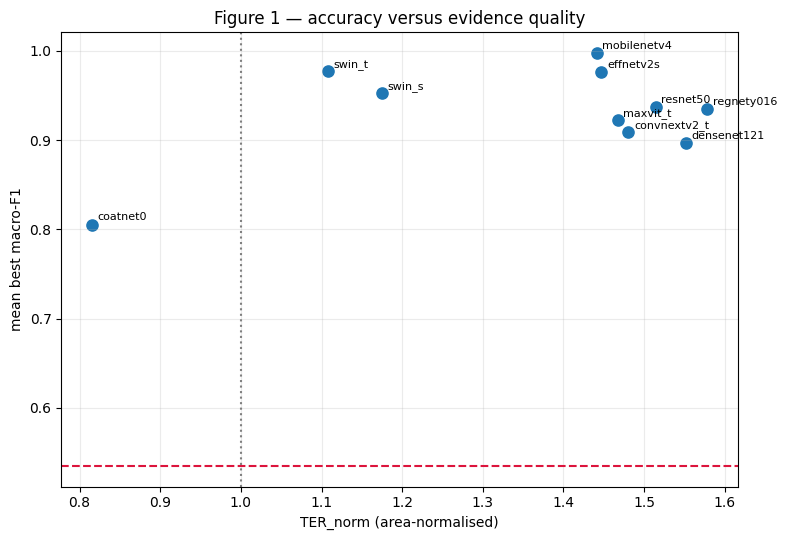

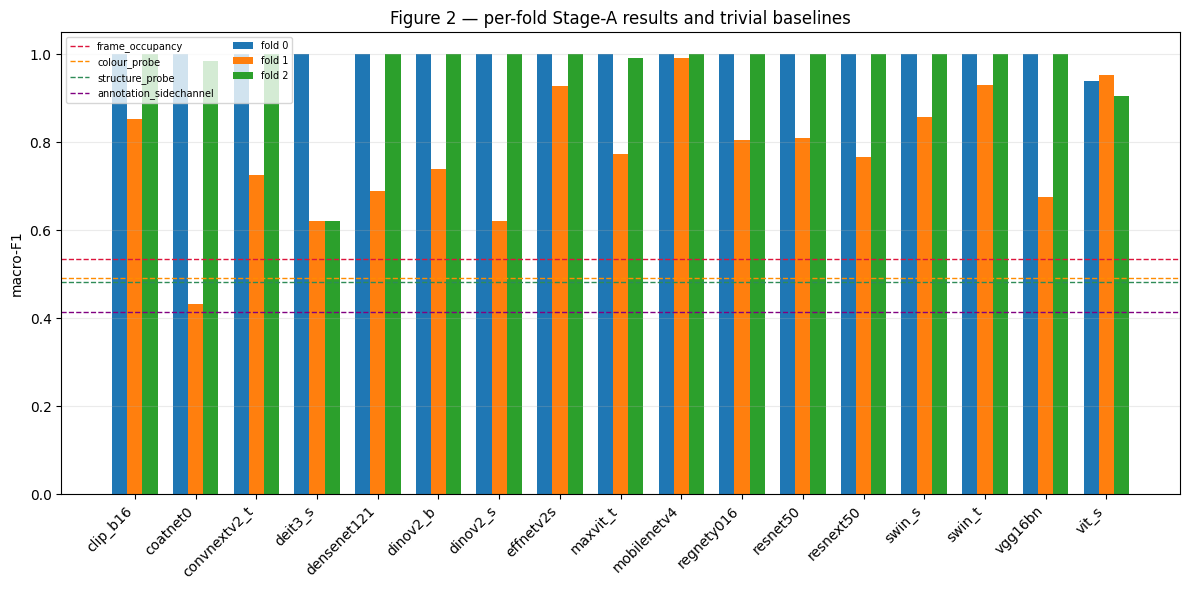

In [14]:
import matplotlib.pyplot as plt

def read_table(name):
    p=LOCAL/"tables"/name
    return pd.read_csv(p) if p.exists() else pd.DataFrame()

EV=read_table("xai_evidence_all.csv"); SEL=read_table("stage_b_selection.csv")
if len(EV):
    xe=EV.groupby("arch").ter_norm.mean(); xa=A.groupby("arch").best_val_f1_macro.mean()
    j=pd.DataFrame({"ter_norm":xe,"macro_f1":xa}).dropna()
    fig,ax=plt.subplots(figsize=(8,5.5)); ax.scatter(j.ter_norm,j.macro_f1,s=65)
    for k,r in j.iterrows(): ax.annotate(k,(r.ter_norm,r.macro_f1),fontsize=8,xytext=(4,3),textcoords="offset points")
    ax.axvline(1,ls=":",c="grey"); ax.axhline(tl.FLOOR,ls="--",c="crimson")
    ax.set(xlabel="TER_norm (area-normalised)",ylabel="mean best macro-F1",
           title="Figure 1 — accuracy versus evidence quality")
    ax.grid(alpha=.25); fig.tight_layout(); fig.savefig(OUT/"fig01_accuracy_vs_ter.png",dpi=170); plt.show()
else: print("Figure 1 skipped: run NB07")

piv=A.pivot_table(index="arch",columns="fold",values="best_val_f1_macro").sort_index()
fig,ax=plt.subplots(figsize=(12,6)); x=np.arange(len(piv)); w=.25
for i,f in enumerate(piv.columns): ax.bar(x+(i-1)*w,piv[f],w,label=f"fold {f}")
for k,c in (("frame_occupancy","crimson"),("colour_probe","darkorange"),
            ("structure_probe","seagreen"),("annotation_sidechannel","purple")):
    ax.axhline(tl.BASELINES[k]["mean"],ls="--",lw=1,c=c,label=k)
ax.set_xticks(x); ax.set_xticklabels(piv.index,rotation=45,ha="right")
ax.set(ylabel="macro-F1",title="Figure 2 — per-fold Stage-A results and trivial baselines")
ax.legend(fontsize=7,ncol=2); ax.grid(axis="y",alpha=.25); fig.tight_layout()
fig.savefig(OUT/"fig02_per_fold.png",dpi=170); plt.show()


## 4 — Figures 3 and 4: saliency examples and causal interventions

Figure 3 skipped: NB07 examples missing


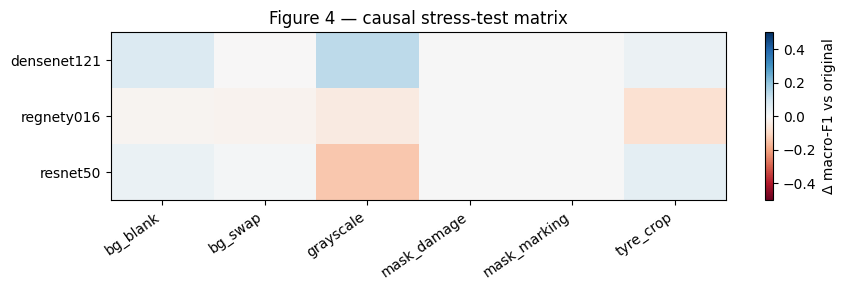

In [15]:
from PIL import Image
imgs=sorted((LOCAL/"analysis"/"xai_examples").glob("*.png"))
if imgs:
    n=len(imgs); cols=4; rows=int(np.ceil(n/cols)); fig,axes=plt.subplots(rows,cols,figsize=(14,3.5*rows))
    axes=np.asarray(axes).reshape(-1)
    for ax,p in zip(axes,imgs): ax.imshow(Image.open(p)); ax.set_title(p.stem); ax.axis("off")
    for ax in axes[len(imgs):]: ax.axis("off")
    fig.suptitle("Figure 3 — same preregistered evidence procedure across architectures")
    fig.tight_layout(); fig.savefig(OUT/"fig03_saliency_panels.png",dpi=160); plt.show()
else: print("Figure 3 skipped: NB07 examples missing")

ST=read_table("stress_tests.csv")
if len(ST):
    p=ST.pivot_table(index="arch",columns="intervention",values="f1_macro")
    d=p.sub(p["none"],axis=0).drop(columns="none")
    fig,ax=plt.subplots(figsize=(9,max(3,.7*len(d)))); im=ax.imshow(d.values,aspect="auto",cmap="RdBu",vmin=-.5,vmax=.5)
    ax.set_xticks(range(len(d.columns))); ax.set_xticklabels(d.columns,rotation=35,ha="right")
    ax.set_yticks(range(len(d))); ax.set_yticklabels(d.index); plt.colorbar(im,ax=ax,label="Δ macro-F1 vs original")
    ax.set_title("Figure 4 — causal stress-test matrix"); fig.tight_layout()
    fig.savefig(OUT/"fig04_stress_matrix.png",dpi=170); plt.show()
else: print("Figure 4 skipped: run NB08")


## 5 — Figure 5 and preregistered H1–H3 outcomes

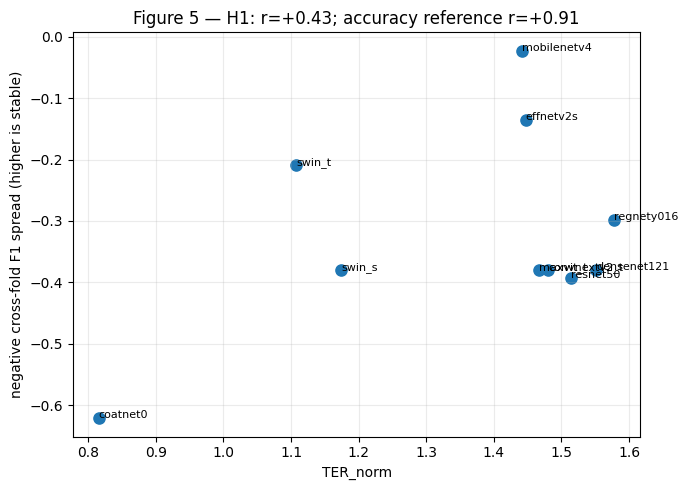

hypothesis  n  stat_primary  stat_reference supported                                                                        reading
        H1 10        0.4271          0.9074     False                              corr(TER, stability) vs corr(accuracy, stability)
        H3  0           NaN             NaN      None NOT TESTABLE YET: Stage A contains no preregistered fine-grained architectures
        H2  3           NaN             NaN     False        corr(SAR, marking dependence); reference=corr(DmgAR, damage dependence)


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [16]:
outcomes=[]
if len(EV):
    ter=EV.groupby("arch").ter_norm.mean(); per=A.groupby("arch").best_val_f1_macro
    J=pd.DataFrame({"ter_norm":ter,"accuracy":per.mean(),
                    "stability":-(per.max()-per.min())}).dropna()
    rter=float(J.ter_norm.corr(J.stability)); racc=float(J.accuracy.corr(J.stability))
    outcomes.append({"hypothesis":"H1","n":len(J),"stat_primary":rter,"stat_reference":racc,
                     "supported":abs(rter)>abs(racc),
                     "reading":"corr(TER, stability) vs corr(accuracy, stability)"})
    fig,ax=plt.subplots(figsize=(7,5)); ax.scatter(J.ter_norm,J.stability,s=65)
    for k,r in J.iterrows(): ax.annotate(k,(r.ter_norm,r.stability),fontsize=8)
    ax.set(xlabel="TER_norm",ylabel="negative cross-fold F1 spread (higher is stable)",
           title=f"Figure 5 — H1: r={rter:+.2f}; accuracy reference r={racc:+.2f}")
    ax.grid(alpha=.25); fig.tight_layout(); fig.savefig(OUT/"fig05_h1_stability.png",dpi=170); plt.show()

    fine={"bilinear_cnn","hbp","csab"}
    n_fine=int(pd.Index(ter.index).isin(fine).sum())
    outcomes.append({"hypothesis":"H3","n":n_fine,"stat_primary":np.nan,"stat_reference":np.nan,
                     "supported":None,
                     "reading":"NOT TESTABLE YET: Stage A contains no preregistered fine-grained architectures"})

if len(EV) and len(ST):
    e=EV.groupby("arch").agg(sar=("sar","mean"),dmgar=("dmgar","mean"))
    s=ST.pivot_table(index="arch",columns="intervention",values=["recall_low","recall_high"])
    mark=s[("recall_low","mask_marking")]-s[("recall_low","none")]
    dmg=s[("recall_high","mask_damage")]-s[("recall_high","none")]
    h2=e.join(pd.DataFrame({"mark_dependence":-mark,"damage_dependence":-dmg})).dropna()
    rs=float(h2.sar.corr(h2.mark_dependence)); rd=float(h2.dmgar.corr(h2.damage_dependence))
    outcomes.append({"hypothesis":"H2","n":len(h2),"stat_primary":rs,"stat_reference":rd,
                     "supported":bool(rs>0 and rd>0),
                     "reading":"corr(SAR, marking dependence); reference=corr(DmgAR, damage dependence)"})

H=pd.DataFrame(outcomes); H.to_csv(TAB/"hypothesis_outcomes.csv",index=False)
print(H.round(4).to_string(index=False) if len(H) else "H1-H3 unavailable until NB07/NB08 complete")


## 6 — Figures 6 and 7: OFAT effects and attribution faithfulness

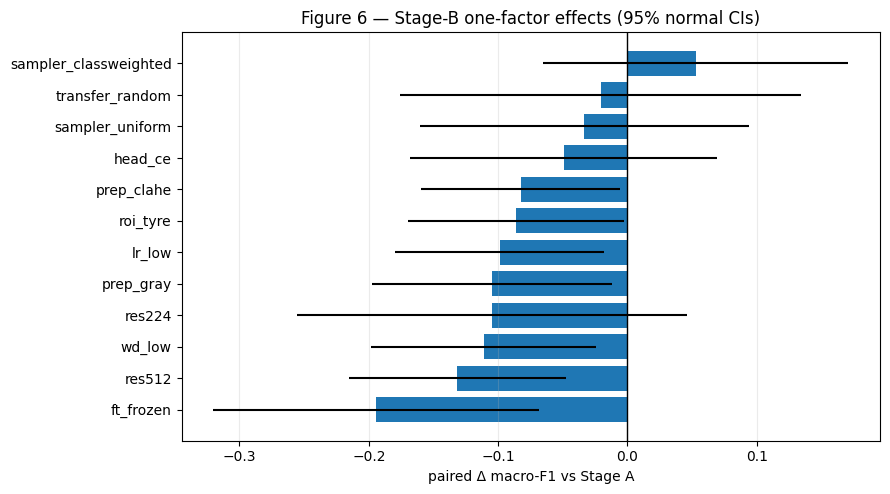

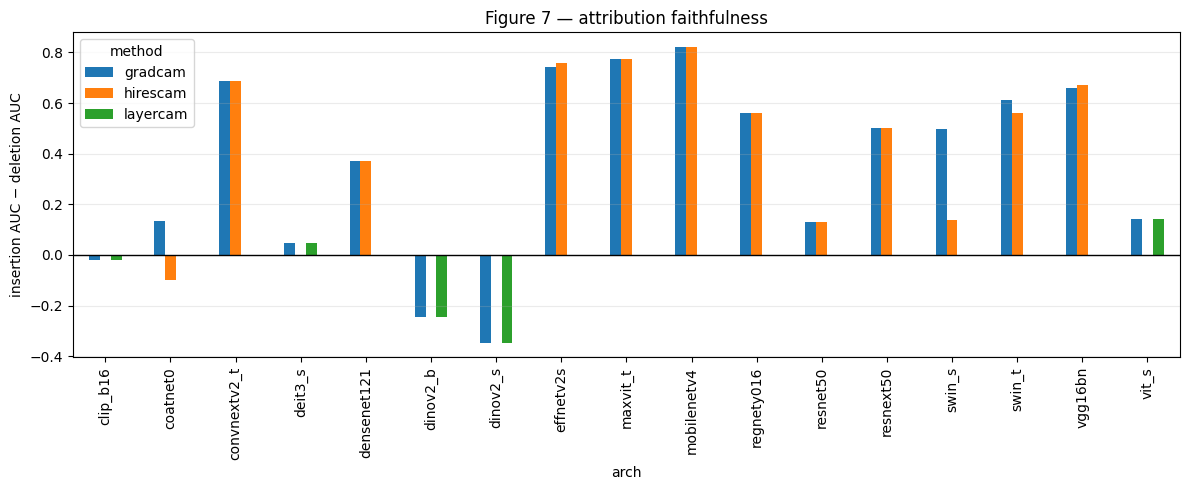

In [17]:
EFF=read_table("stage_b_effects.csv")
if len(EFF):
    g=EFF.groupby("factor").delta_vs_stage_a.agg(["mean","std","count"]).sort_values("mean")
    g["ci95"]=1.96*g["std"]/np.sqrt(g["count"].clip(lower=1))
    fig,ax=plt.subplots(figsize=(9,max(4,.42*len(g)))); ax.barh(g.index,g["mean"],xerr=g.ci95)
    ax.axvline(0,c="black",lw=1); ax.set(xlabel="paired Δ macro-F1 vs Stage A",
        title="Figure 6 — Stage-B one-factor effects (95% normal CIs)")
    ax.grid(axis="x",alpha=.25); fig.tight_layout(); fig.savefig(OUT/"fig06_ofat_effects.png",dpi=170); plt.show()
else: print("Figure 6 skipped: Stage B effects not complete")

FA=read_table("xai_faithfulness.csv")
if len(FA):
    FA["faithfulness"]=FA.insertion_auc-FA.deletion_auc
    q=FA.pivot_table(index="arch",columns="method",values="faithfulness")
    ax=q.plot.bar(figsize=(12,5)); ax.axhline(0,c="black",lw=1)
    ax.set(ylabel="insertion AUC − deletion AUC",title="Figure 7 — attribution faithfulness")
    ax.grid(axis="y",alpha=.25); plt.tight_layout(); plt.savefig(OUT/"fig07_faithfulness.png",dpi=170); plt.show()
else: print("Figure 7 skipped: run NB07")


## 7 — Figures 8 and 9: convergence and energy

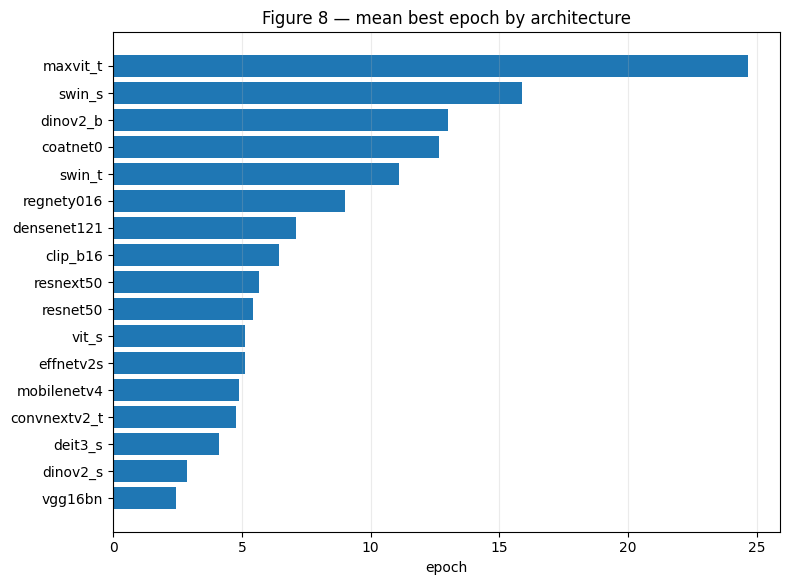

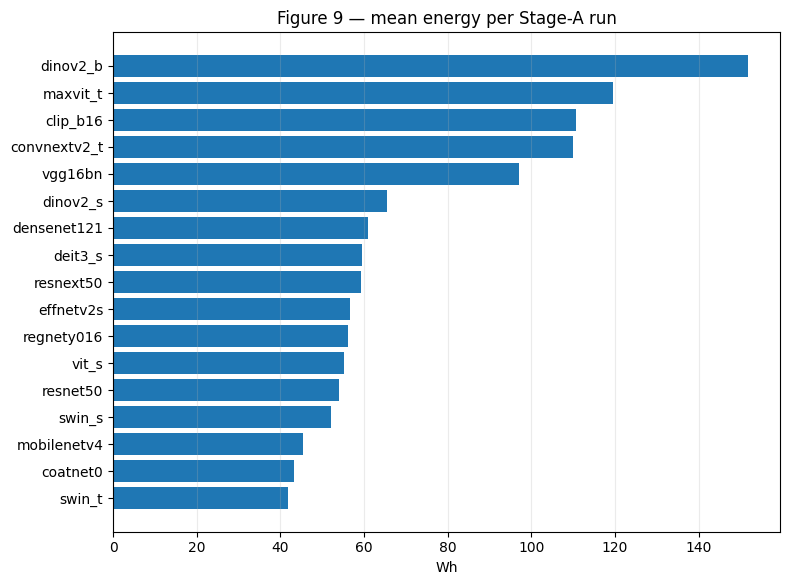

In [18]:
for num,col,title,unit,name in [
    (8,"best_epoch","Figure 8 — mean best epoch by architecture","epoch","fig08_best_epoch.png"),
    (9,"total_energy_wh","Figure 9 — mean energy per Stage-A run","Wh","fig09_energy.png")]:
    g=A.groupby("arch")[col].mean().sort_values()
    fig,ax=plt.subplots(figsize=(8,max(4,.35*len(g)))); ax.barh(g.index,g.values)
    ax.set(xlabel=unit,title=title); ax.grid(axis="x",alpha=.25); fig.tight_layout()
    fig.savefig(OUT/name,dpi=170); plt.show()


## 8 — Figure 10: validation-session heat map

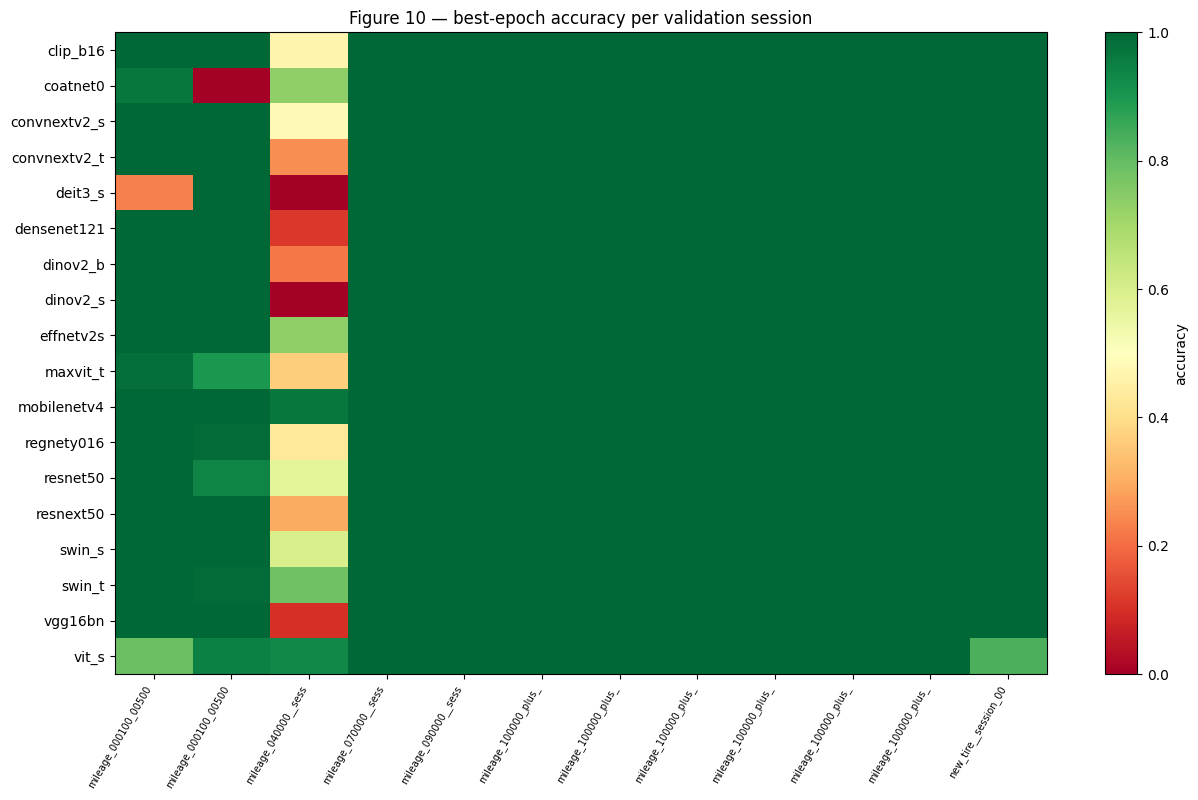

In [19]:
rows=[]
for f in sorted(LOCAL.glob("runs/a-*/metrics/epochs.csv")):
    try:
        e=pd.read_csv(f)
        if not len(e): continue
        best=e.loc[e.val_qwk.idxmax()]
        arch=str(best.get("arch",f.parts[-3].split("-")[1]))
        for col in e.columns:
            if col.startswith("val_acc_session_"):
                rows.append({"arch":arch,"session":col.replace("val_acc_session_",""),"acc":best[col]})
    except Exception: pass
if rows:
    Q=pd.DataFrame(rows).pivot_table(index="arch",columns="session",values="acc")
    fig,ax=plt.subplots(figsize=(13,max(4,.45*len(Q)))); im=ax.imshow(Q.values,aspect="auto",vmin=0,vmax=1,cmap="RdYlGn")
    ax.set_xticks(range(len(Q.columns))); ax.set_xticklabels([x[:20] for x in Q.columns],rotation=60,ha="right",fontsize=7)
    ax.set_yticks(range(len(Q))); ax.set_yticklabels(Q.index); plt.colorbar(im,ax=ax,label="accuracy")
    ax.set_title("Figure 10 — best-epoch accuracy per validation session")
    fig.tight_layout(); fig.savefig(OUT/"fig10_per_session.png",dpi=170); plt.show()
else: print("Figure 10 skipped: per-session epoch columns unavailable")


## 9 — Push derived tables and figures

In [20]:
sess.uploader.enqueue_dir(OUT,"analysis",force=True)
sess.uploader.enqueue_dir(TAB,"tables",force=True)
sess.push_now("NB10 analysis complete"); sess.finish()
print("analysis complete")


[HF] flush (NB10 analysis complete): 16 file(s)


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

[HF] commit #1: 16 file(s), 0.8 MB, 2.4s  [1/25 this hr]
[SESSION] final flush -- blocking until HuggingFace confirms
[SESSION] done. commits=1 failures=0 pushed=1 MB
analysis complete
